<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> Data Science Capstone - 1 <br>
<b>Semester:</b> Summer 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 2 - Linear Regression: Part 2 | Lasso, Ridge, and Elastic Net Regression

# Homework - Working On My Datasets

### Packages

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing and splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegressionCV

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Display settings
pd.set_option("display.max_columns", None)

### IMPORTANT NOTE:
- Because the target variable of our Diabetes Dataset contains three categories, this is a **multiclass classification problem, not a regression problem**.

- The three target classes are:
    - 0 = No diabetes
    - 1 = Prediabetes
    - 2 = Diabetes

- Since Week 2 covered **Lasso, Ridge, and Elastic Net regression**, we apply the same **regularization ideas using logistic regression penalties**:
    - Ridge-style classification      → Logistic Regression with L2 penalty
    - Lasso-style classification      → Logistic Regression with L1 penalty
    - Elastic Net classification      → Logistic Regression with elasticnet penalty

## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

#### [Dataset 1] | *1- Load the dataset & quick preview*

In [2]:
# Load the dataset
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

# Display the first few rows
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


- The dataset contains **health, lifestyle, and demographic variables** from the CDC BRFSS 2015 survey.

- The target variable is **Diabetes_012**, which identifies whether the person has **no diabetes, prediabetes, or diabetes**.

- The goal is to use the available health indicators to predict diabetes status.

#### [Dataset 1] | *2- Inspect the dataset structure*

In [3]:
# Check dataset shape
print("Dataset shape:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns.tolist())

# Check basic information
df.info()

Dataset shape: (253680, 22)

Column names:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float

- From inspecting the uploaded CSV file, the dataset contains:
    - 253,680 rows
    - 22 columns

- The first column, Diabetes_012, is the target variable. The remaining 21 columns are predictor variables.

- The feature columns include variables such as:
    - HighBP
    - HighChol
    - BMI
    - Smoker
    - Stroke
    - HeartDiseaseorAttack
    - PhysActivity
    - Fruits
    - Veggies
    - GenHlth
    - MentHlth
    - PhysHlth
    - DiffWalk
    - Sex
    - Age
    - Education
    - Income

- Most variables are binary or ordinal health indicators.

- BMI, MentHlth, and PhysHlth are numeric variables.

#### [Dataset 1] | *3- Check missing values*

In [4]:
# Check missing values in each column
missing_values = df.isnull().sum()

missing_values

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

- If a dataset has missing values, we usually need to decide whether to remove rows, impute missing values, or handle missingness in another way.

- For this dataset, the uploaded CSV does not contain missing values, so we can continue without imputation.

#### [Dataset 1] | *4- Examine the target variable*

In [6]:
# Count the number of observations in each diabetes class
target_counts = df["Diabetes_012"].value_counts().sort_index()

print(target_counts)

# Convert counts to percentages
target_percentages = df["Diabetes_012"].value_counts(normalize=True).sort_index() * 100

print("\nClass percentages:")
print(target_percentages)

Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

Class percentages:
Diabetes_012
0.0    84.241170
1.0     1.825528
2.0    13.933302
Name: proportion, dtype: float64


- The target variable Diabetes_012 has three classes:
    - 0 = No diabetes
    - 1 = Prediabetes
    - 2 = Diabetes

- From the uploaded dataset, the class counts are:
    - 0.0 → 213,703
    - 1.0 → 4,631
    - 2.0 → 35,346

- This shows that the dataset is highly **imbalanced**. The majority class is 0, meaning no diabetes. The prediabetes class, 1, is much smaller than the other two classes.

- This is important because a model could achieve high overall accuracy by mostly predicting the majority class. Therefore, we should not rely only on accuracy. We should also use metrics such as:
    - balanced accuracy
    - macro F1-score
    - class-specific precision
    - class-specific recall
    - class-specific F1-score


#### [Dataset 1] | *5- Visualize the target distribution*

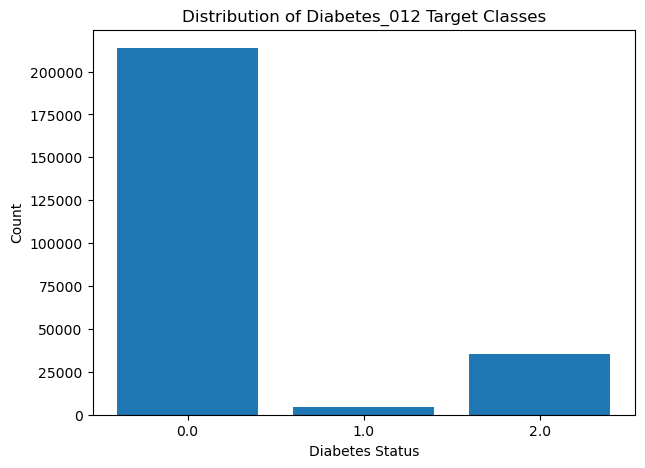

In [7]:
# Plot target class distribution
plt.figure(figsize=(7, 5))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.title("Distribution of Diabetes_012 Target Classes")
plt.show()

- This bar chart visualizes the class imbalance in the target variable.

- The class 0, no diabetes, is much more frequent than the prediabetes and diabetes classes. This imbalance affects model training and evaluation.

- Because of this imbalance, we will use **class_weight="balanced"** in our logistic regression models. This gives more weight to minority classes during training.

#### [Dataset 1] | *6- Separate features and target + Train-test split*

In [8]:
# Separate target and features
X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Feature matrix shape: (253680, 21)
Target vector shape: (253680,)
Training feature shape: (202944, 21)
Testing feature shape: (50736, 21)

Training target distribution:
Diabetes_012
0.0    0.842410
1.0    0.018256
2.0    0.139334
Name: proportion, dtype: float64

Testing target distribution:
Diabetes_012
0.0    0.842420
1.0    0.018251
2.0    0.139329
Name: proportion, dtype: float64


- We use: **stratify=y**

- This preserves the same class distribution in both the training and testing sets. This is especially important because the dataset is imbalanced.

#### [Dataset 1] | *7- Create a helper function for model evaluation*

In [9]:
def evaluate_classifier(model, X_test, y_test, model_name):
    """
    Evaluates a classification model using multiple classification metrics.
    """
    # Generate predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    
    # Store results
    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }
    
    # Print results
    print(f"Results for {model_name}")
    print("-" * 50)
    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Macro F1:          {macro_f1:.4f}")
    print(f"Weighted F1:       {weighted_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return results

- We use:
    - Accuracy
    - Balanced Accuracy
    - Macro F1-score
    - Weighted F1-score
    - Classification report

- Accuracy alone can be **misleading** because the dataset is **imbalanced**.

- **Balanced Accuracy** is useful because it gives equal importance to each class.

- **Macro F1-score** is also useful because it calculates the F1-score for each class independently and then averages them equally. This prevents the majority class from dominating the evaluation.

#### [Dataset 1] | *8- Ridge-style logistic regression using L2 regularization*

In [10]:
# Ridge-style logistic regression using L2 penalty
ridge_logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegressionCV(
            Cs=[0.001, 0.01, 0.1, 1, 10, 100],
            cv=3,
            penalty="l2",
            solver="saga",
            scoring="f1_macro",
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Fit the Ridge-style logistic regression model
ridge_logistic_model.fit(X_train, y_train)

# Evaluate the model
ridge_results = evaluate_classifier(
    ridge_logistic_model,
    X_test,
    y_test,
    "Ridge Logistic Regression - L2"
)

C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

Results for Ridge Logistic Regression - L2
--------------------------------------------------
Accuracy:          0.6458
Balanced Accuracy: 0.5216
Macro F1:          0.4251
Weighted F1:       0.7208

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.67      0.78     42741
         1.0       0.03      0.33      0.06       926
         2.0       0.35      0.57      0.43      7069

    accuracy                           0.65     50736
   macro avg       0.44      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736



- This model applies the Week 2 concept of **Ridge regularization to a classification problem**:
    - In **ordinary Ridge regression**, the model uses an L2 penalty, which penalizes the sum of squared coefficients.
    - In **classification**, we can apply the same idea using **logistic regression** with **penalty="l2"**
        - The **L2 penalty** shrinks coefficients toward zero but usually does not force them exactly to zero.
        - This means Ridge-style logistic regression keeps most or all features in the model while reducing the influence of less important predictors.

- This is useful when several features may contribute to diabetes prediction, but we want to control overfitting

- We use **LogisticRegressionCV** so that cross-validation can choose the best value of **C**.

- **Important note:**
    - C is the inverse of regularization strength.
    - Smaller C = stronger regularization.
    - Larger C = weaker regularization.

- So **C** plays the opposite role of **lambda (ordinary ridge regression)**.

#### [Dataset 1] | *9- Lasso-style logistic regression using L1 regularization*

In [11]:
# Lasso-style logistic regression using L1 penalty
lasso_logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegressionCV(
            Cs=[0.001, 0.01, 0.1, 1, 10, 100],
            cv=3,
            penalty="l1",
            solver="saga",
            scoring="f1_macro",
            class_weight="balanced",
            max_iter=3000,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Fit the Lasso-style logistic regression model
lasso_logistic_model.fit(X_train, y_train)

# Evaluate the model
lasso_results = evaluate_classifier(
    lasso_logistic_model,
    X_test,
    y_test,
    "Lasso Logistic Regression - L1"
)

C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

Results for Lasso Logistic Regression - L1
--------------------------------------------------
Accuracy:          0.5997
Balanced Accuracy: 0.4895
Macro F1:          0.3918
Weighted F1:       0.6879

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.63      0.76     42741
         1.0       0.03      0.37      0.06       926
         2.0       0.30      0.47      0.36      7069

    accuracy                           0.60     50736
   macro avg       0.43      0.49      0.39     50736
weighted avg       0.84      0.60      0.69     50736



C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


- This model applies the Week 2 concept of **Lasso regularization to the classification problem**:
    - In **ordinary Lasso regression**, the model uses an L1 penalty, which penalizes the sum of the absolute values of the coefficients.
    - In **logistic regression**, we apply the same idea using **penalty="l1"**
        - Lasso-style logistic regression can shrink some coefficients exactly to zero.
- This means Lasso can perform **feature selection** :
    - If a feature receives a coefficient of zero, the model is effectively ignoring that feature for prediction.
    - This is useful when we believe only some of the health indicators are strongly related to diabetes status.

- Because the dataset has many correlated health variables, Lasso may select one variable from a group of related predictors and shrink others to zero.

#### [Dataset 1] | *10- Elastic Net logistic regression*

In [12]:
# Elastic Net logistic regression using combined L1 and L2 penalty
elastic_net_logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegressionCV(
            Cs=[0.001, 0.01, 0.1, 1, 10, 100],
            cv=3,
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[0.2, 0.5, 0.8],
            scoring="f1_macro",
            class_weight="balanced",
            max_iter=3000,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Fit the Elastic Net logistic regression model
elastic_net_logistic_model.fit(X_train, y_train)

# Evaluate the model
elastic_net_results = evaluate_classifier(
    elastic_net_logistic_model,
    X_test,
    y_test,
    "Elastic Net Logistic Regression"
)

C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\jasse\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter 

Results for Elastic Net Logistic Regression
--------------------------------------------------
Accuracy:          0.6500
Balanced Accuracy: 0.5203
Macro F1:          0.4271
Weighted F1:       0.7229

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.67      0.78     42741
         1.0       0.03      0.31      0.06       926
         2.0       0.35      0.59      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.44      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736



- This model applies the Week 2 concept of **Elastic Net regularization to classification**:
    - **Elastic Net** combines both **L1 and L2 penalties**.
    - In **logistic regression**, we use **penalty="elasticnet"**

- The **l1_ratio** controls the balance between Lasso and Ridge behavior:
    - l1_ratio = 0.0 → pure Ridge behavior
    - l1_ratio = 1.0 → pure Lasso behavior
    - l1_ratio between 0 and 1 → Elastic Net

- In this notebook, we test: l1_ratios=[0.2, 0.5, 0.8]
    - This allows cross-validation to choose whether the model should behave more like Ridge, more like Lasso, or somewhere in between.

- Elastic Net is especially useful when predictors are correlated because it can keep groups of related variables while still performing some feature selection.

#### [Dataset 1] | *11- Compare model performance*

In [13]:
# Combine all model results into a DataFrame
results_df = pd.DataFrame([
    ridge_results,
    lasso_results,
    elastic_net_results
])

# Sort by Macro F1 because this is useful for imbalanced multiclass classification
results_df = results_df.sort_values(by="Macro F1", ascending=False)

results_df

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
2,Elastic Net Logistic Regression,0.649972,0.520327,0.427107,0.722873
0,Ridge Logistic Regression - L2,0.645833,0.521561,0.425071,0.720770
1,Lasso Logistic Regression - L1,0.599673,0.489478,0.391768,0.687927


- Because this is an imbalanced multiclass classification problem, we should pay special attention to:
    - Balanced Accuracy
    - Macro F1

#### [Dataset 1] | *12- Plot model comparison*

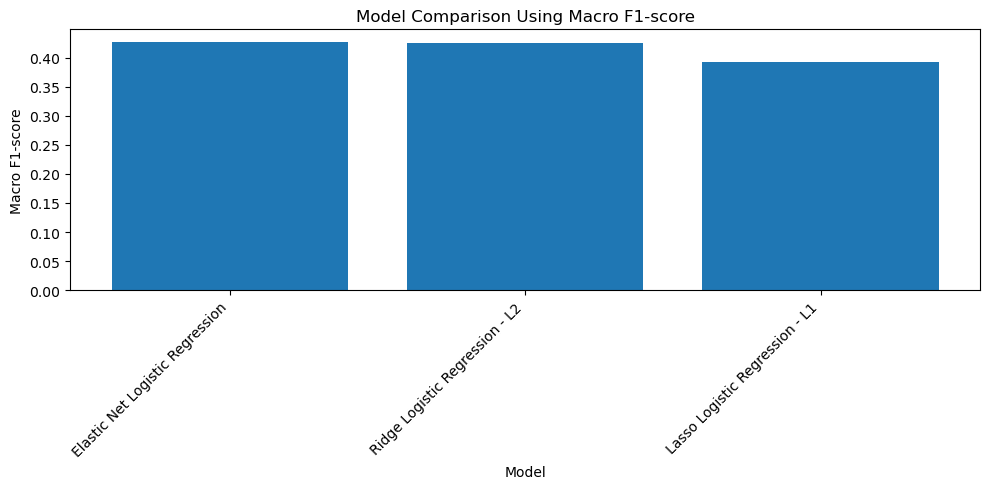

In [14]:
# Plot Macro F1 comparison
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Macro F1"])
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.title("Model Comparison Using Macro F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### [Dataset 1] | *13- Display confusion matrix for the best model*

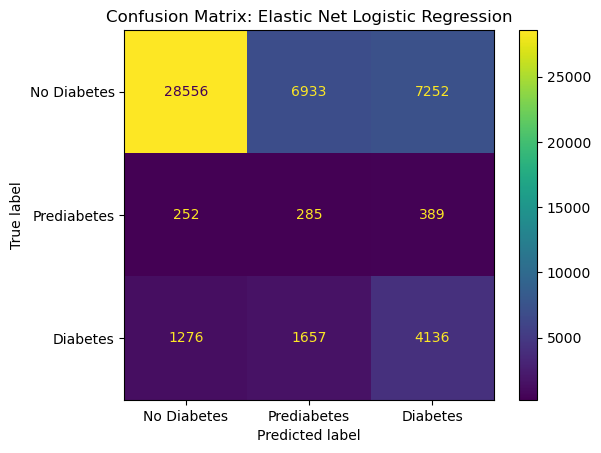

In [15]:
# Select the best model based on Macro F1-score
best_model_name = results_df.iloc[0]["Model"]

if best_model_name == "Ridge Logistic Regression - L2":
    best_model = ridge_logistic_model
elif best_model_name == "Lasso Logistic Regression - L1":
    best_model = lasso_logistic_model
elif best_model_name == "Elastic Net Logistic Regression":
    best_model = elastic_net_logistic_model
else:
    best_model = baseline_model

# Generate predictions
y_pred_best = best_model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

- The confusion matrix shows how the best model performs for each diabetes class.

- This helps us see where the model is making mistakes.

    - For example, we can observe whether the model often confuses:

        - Prediabetes with no diabetes
        - Diabetes with no diabetes
        - Prediabetes with diabetes

- This is important because in healthcare-related classification problems, the type of error matters.

- Missing people with diabetes or prediabetes may be more serious than incorrectly flagging someone as at risk.

#### [Dataset 1] | *14- Extract best hyperparameters*

In [16]:
# Function to extract best hyperparameters from a fitted pipeline
def extract_best_params(model_pipeline, model_name):
    model = model_pipeline.named_steps["model"]
    
    print(f"Best hyperparameters for {model_name}")
    print("-" * 60)
    
    # C values are stored per class in multinomial setting
    print("Best C values:")
    print(model.C_)
    
    # Elastic Net also has l1_ratio_
    if hasattr(model, "l1_ratio_"):
        print("\nBest l1_ratio values:")
        print(model.l1_ratio_)

# Extract selected hyperparameters
extract_best_params(ridge_logistic_model, "Ridge Logistic Regression - L2")
extract_best_params(lasso_logistic_model, "Lasso Logistic Regression - L1")
extract_best_params(elastic_net_logistic_model, "Elastic Net Logistic Regression")

Best hyperparameters for Ridge Logistic Regression - L2
------------------------------------------------------------
Best C values:
[0.01 0.01 0.01]

Best l1_ratio values:
[None None None]
Best hyperparameters for Lasso Logistic Regression - L1
------------------------------------------------------------
Best C values:
[0.001 0.001 0.001]

Best l1_ratio values:
[None None None]
Best hyperparameters for Elastic Net Logistic Regression
------------------------------------------------------------
Best C values:
[0.001 0.001 0.001]

Best l1_ratio values:
[0.8 0.8 0.8]


- This step displays the best regularization settings selected by cross-validation.

- For logistic regression in scikit-learn, the regularization strength is controlled by C.

    - The relationship is: C = inverse of lambda

    - So:

        - Small C  → stronger regularization
        - Large C  → weaker regularization

- For Elastic Net, we also inspect l1_ratio.

    - The selected l1_ratio tells us whether the model preferred more Ridge-like or more Lasso-like behavior:
        - l1_ratio = 1.0 (Pure Lasso)
        - l1_ratio = 0.0 (Pure Ridge)
        - l1_ratio = 0.5 (Perfect Balance)

#### [Dataset 1] | *15- Extract coefficients from the Ridge model*

In [17]:
# Extract feature names
feature_names = X.columns

# Extract coefficients from Ridge-style logistic regression
ridge_coefficients = ridge_logistic_model.named_steps["model"].coef_

# Convert to DataFrame
ridge_coef_df = pd.DataFrame(
    ridge_coefficients,
    columns=feature_names,
    index=["Class 0: No Diabetes", "Class 1: Prediabetes", "Class 2: Diabetes"]
)

ridge_coef_df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Class 0: No Diabetes,-0.178254,-0.198253,-0.137757,-0.316716,-0.003057,-0.001441,-0.023818,0.016006,0.015773,0.009209,0.076985,-0.003130,-0.041941,-0.342485,-0.011293,0.040634,-0.000022,-0.061685,-0.317782,0.038769,0.098990
Class 1: Prediabetes,0.000872,0.068037,0.021731,0.108390,-0.019270,-0.029450,-0.041284,0.006842,-0.006083,0.008236,0.033336,0.008593,0.050110,0.036405,0.050206,0.011844,-0.022619,-0.017594,0.158326,-0.036795,-0.067009
Class 2: Diabetes,0.177382,0.130216,0.116026,0.208326,0.022327,0.030890,0.065102,-0.022848,-0.009690,-0.017446,-0.110321,-0.005463,-0.008169,0.306080,-0.038913,-0.052478,0.022641,0.079279,0.159456,-0.001973,-0.031982


- Because this is a **multiclass classification** problem, the model learns a separate set of **coefficients for each class**.

- A **positive** coefficient means that higher values of that feature increase the model’s tendency to predict that class, relative to the other classes.

- A **negative** coefficient means that higher values of that feature decrease the model’s tendency to predict that class.

- Because Ridge uses L2 regularization, most coefficients are usually nonzero but shrunk toward smaller values.

#### [Dataset 1] | *16- Extract coefficients from the Lasso model*

In [18]:
# Extract coefficients from Lasso-style logistic regression
lasso_coefficients = lasso_logistic_model.named_steps["model"].coef_

# Convert to DataFrame
lasso_coef_df = pd.DataFrame(
    lasso_coefficients,
    columns=feature_names,
    index=["Class 0: No Diabetes", "Class 1: Prediabetes", "Class 2: Diabetes"]
)

lasso_coef_df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Class 0: No Diabetes,-0.153713,-0.234958,-0.157636,-0.379544,0.026242,0.017150,-0.028951,-0.012673,0.009943,0.005239,-0.002813,-0.037980,-0.022718,-0.320311,-0.039237,0.027612,0.027844,-0.049999,-0.404210,0.008784,0.092719
Class 1: Prediabetes,0.017550,0.101389,0.018762,-0.046590,0.120488,0.117301,-0.099805,-0.119417,-0.025194,0.131428,0.006652,0.380101,0.330341,-0.114073,-0.243601,0.004595,-0.003237,-0.054028,-0.001481,-0.107710,-0.045555
Class 2: Diabetes,0.196071,-0.063411,0.090566,0.120781,-0.153135,-0.130583,0.168908,0.104035,0.002602,-0.147775,-0.150790,-0.346656,-0.275918,0.317550,0.324827,-0.058817,-0.022805,0.111117,0.061074,0.039999,-0.036087


- Because Lasso uses L1 regularization, some coefficients may become exactly zero.

- A coefficient of zero means the model did not use that feature for predicting that specific class.

- This is how Lasso performs feature selection.

- In this diabetes classification problem, Lasso may help identify which health indicators are most useful for predicting diabetes status.

#### [Dataset 1] | *17- Identify features selected by Lasso*

In [19]:
# Count how many coefficients are zero for each feature across all classes
lasso_zero_counts = (lasso_coef_df == 0).sum(axis=0)

# Count how many coefficients are nonzero for each feature across all classes
lasso_nonzero_counts = (lasso_coef_df != 0).sum(axis=0)

# Create summary table
lasso_feature_selection = pd.DataFrame({
    "Feature": feature_names,
    "Nonzero Coefficients Across Classes": lasso_nonzero_counts.values,
    "Zero Coefficients Across Classes": lasso_zero_counts.values
})

# Sort by number of nonzero coefficients
lasso_feature_selection = lasso_feature_selection.sort_values(
    by="Nonzero Coefficients Across Classes",
    ascending=False
)

lasso_feature_selection

,Feature,Nonzero Coefficients Across Classes,Zero Coefficients Across Classes
0,HighBP,3,0
11,AnyHealthcare,3,0
19,Education,3,0
18,Age,3,0
17,Sex,3,0
16,DiffWalk,3,0
15,PhysHlth,3,0
14,MentHlth,3,0
13,GenHlth,3,0
12,NoDocbcCost,3,0


- This step summarizes the **feature selection behavior of Lasso**.

- For each feature, we count **how many class-specific coefficients are nonzero**.

- Since there are three classes, each feature can have up to three coefficients:

    - One coefficient for class 0
    - One coefficient for class 1
    - One coefficient for class 2

- If a feature has many zero coefficients, Lasso is reducing the importance of that feature.

- If a feature has nonzero coefficients across multiple classes, Lasso considers that feature useful for distinguishing diabetes status.

- This connects directly to the Week 2 idea that Lasso can shrink some coefficients to zero and therefore remove less useful predictors

#### [Dataset 1] | *18- Extract coefficients from the Elastic Net model*

In [20]:
# Extract coefficients from Elastic Net logistic regression
elastic_net_coefficients = elastic_net_logistic_model.named_steps["model"].coef_

# Convert to DataFrame
elastic_net_coef_df = pd.DataFrame(
    elastic_net_coefficients,
    columns=feature_names,
    index=["Class 0: No Diabetes", "Class 1: Prediabetes", "Class 2: Diabetes"]
)

elastic_net_coef_df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Class 0: No Diabetes,-0.175118,-0.276646,-0.122813,-0.390965,0.0,0.000000,0.00000,0.000698,0.008426,0.002243,0.020150,0.000000,-0.004478,-0.353094,0.000000,0.003269,0.000000,-0.029315,-0.414256,0.033983,0.132807
Class 1: Prediabetes,0.000000,0.000000,0.000000,0.000000,0.0,-0.010670,0.00000,0.000000,0.000000,0.000000,0.000000,-0.008342,0.065352,0.000000,0.040697,0.000000,-0.005306,0.000000,0.000000,-0.024476,-0.004497
Class 2: Diabetes,0.186892,0.006042,0.052202,0.111216,0.0,0.030925,0.07082,-0.013671,-0.001493,0.000000,-0.116095,0.002139,0.000000,0.241263,-0.012909,0.000000,0.023402,0.070883,0.051588,0.000000,0.000000


- Elastic Net combines both Ridge and Lasso behavior.

- This means it can:

    - Shrink coefficients like Ridge
    - Set some coefficients to zero like Lasso
    - Handle correlated predictors better than pure Lasso

- In this dataset, many health indicators may be related to each other. For example, general health, physical health, difficulty walking, high blood pressure, and BMI may all be connected.

- Elastic Net is useful because it can keep groups of related predictors while still reducing the influence of less useful variables.

#### [Dataset 1] | *19- Compare coefficient magnitudes across models*

In [21]:
# Calculate mean absolute coefficient for each feature in each model
ridge_importance = np.abs(ridge_coef_df).mean(axis=0)
lasso_importance = np.abs(lasso_coef_df).mean(axis=0)
elastic_net_importance = np.abs(elastic_net_coef_df).mean(axis=0)

# Combine into one DataFrame
coefficient_comparison = pd.DataFrame({
    "Feature": feature_names,
    "Ridge Mean Abs Coefficient": ridge_importance.values,
    "Lasso Mean Abs Coefficient": lasso_importance.values,
    "Elastic Net Mean Abs Coefficient": elastic_net_importance.values
})

# Sort by Elastic Net importance
coefficient_comparison = coefficient_comparison.sort_values(
    by="Elastic Net Mean Abs Coefficient",
    ascending=False
)

coefficient_comparison

,Feature,Ridge Mean Abs Coefficient,Lasso Mean Abs Coefficient,Elastic Net Mean Abs Coefficient
13,GenHlth,0.228324,0.250645,0.198119
3,BMI,0.211144,0.182305,0.167394
18,Age,0.211855,0.155588,0.155281
0,HighBP,0.118836,0.122445,0.120670
1,HighChol,0.132168,0.133253,0.094229
2,CholCheck,0.091838,0.088988,0.058338
20,Income,0.065994,0.058120,0.045768
10,HvyAlcoholConsump,0.073548,0.053418,0.045415
17,Sex,0.052853,0.071715,0.033399
6,HeartDiseaseorAttack,0.043401,0.099221,0.023607


- This step compares the **average absolute coefficient size** for each feature across the three regularized logistic regression models.

- The absolute coefficient size gives a rough measure of feature importance.

- However, coefficient interpretation should be done carefully because:

    - Features are scaled before modeling.
    - Coefficients are class-specific.
    - Some variables are binary while others are ordinal or continuous.
    - Correlation among predictors can affect coefficient values.

- Still, this table helps us compare how Ridge, Lasso, and Elastic Net treat the features differently.

    - Ridge usually keeps more features with smaller coefficients.

    - Lasso may set some coefficients to zero.

    - Elastic Net usually gives a balance between the two.

#### [Dataset 1] | *20- Plot top Elastic Net coefficients for diabetes class*

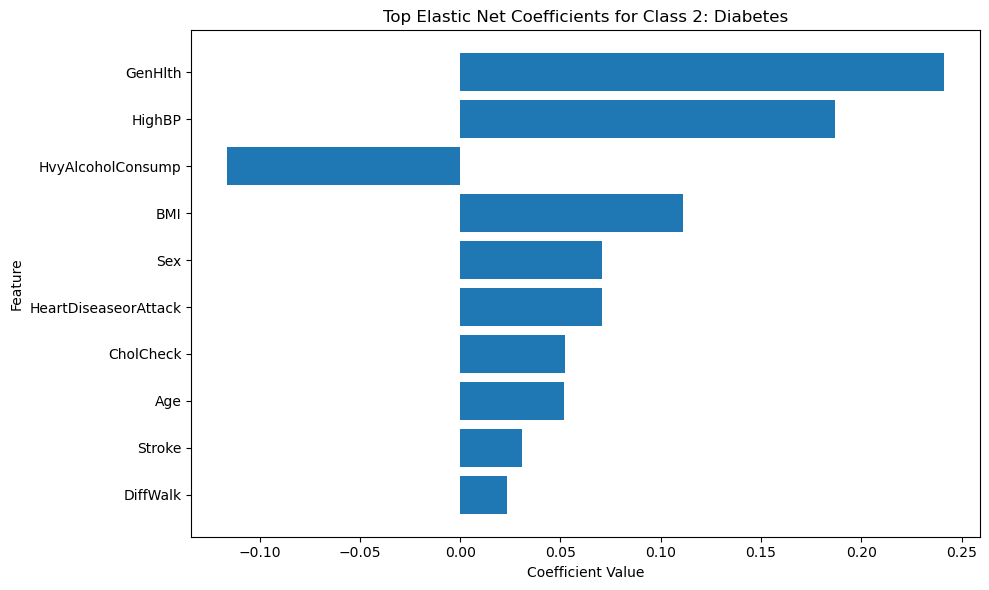

In [22]:
# Focus on Class 2: Diabetes
diabetes_class_coefficients = elastic_net_coef_df.loc["Class 2: Diabetes"]

# Get top 10 features by absolute coefficient size
top_diabetes_features = diabetes_class_coefficients.abs().sort_values(ascending=False).head(10)

# Keep original signs
top_diabetes_coefficients = diabetes_class_coefficients[top_diabetes_features.index]

# Plot top coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_diabetes_coefficients.index, top_diabetes_coefficients.values)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Elastic Net Coefficients for Class 2: Diabetes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- This step focuses specifically on the class: **2 = Diabetes**

- The chart shows the **top features** that the Elastic Net model uses when predicting diabetes.

- **Positive coefficients** increase the model’s tendency to predict diabetes.

- **Negative coefficients** decrease the model’s tendency to predict diabetes.

- This is useful because it connects the predictive model back to real health indicators:

    - For example, variables such as high blood pressure, BMI, general health, age, and difficulty walking may be important predictors depending on the fitted coefficients.

#### [Dataset 1] | *21- Final classification report for the best model*

In [23]:
# Print final classification report for the best model
print(f"Final Classification Report for Best Model: {best_model_name}")
print("-" * 70)
print(classification_report(y_test, y_pred_best, target_names=[
    "No Diabetes",
    "Prediabetes",
    "Diabetes"
]))

Final Classification Report for Best Model: Elastic Net Logistic Regression
----------------------------------------------------------------------
              precision    recall  f1-score   support

 No Diabetes       0.95      0.67      0.78     42741
 Prediabetes       0.03      0.31      0.06       926
    Diabetes       0.35      0.59      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.44      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736



## Conclusion

This analysis applied Ridge-, Lasso-, and Elastic Net-regularized multinomial logistic regression to predict the three diabetes-status classes: no diabetes, prediabetes, and diabetes. Because the predictors were standardized before model fitting, the coefficient magnitudes can be compared across variables; however, they should be interpreted as changes in class-specific log-odds rather than as causal effects.

Across the three regularization approaches, general health status (`GenHlth`), body mass index (`BMI`), age, high blood pressure (`HighBP`), and high cholesterol (`HighChol`) consistently had some of the largest average absolute coefficients. This indicates that these variables provided the strongest linear separation among the diabetes classes. For the diabetes class specifically, the Elastic Net model assigned the largest positive coefficients to `GenHlth`, `HighBP`, `BMI`, `Sex`, `HeartDiseaseorAttack`, `CholCheck`, and `Age`. Holding the remaining predictors constant, larger values of these variables increased the model's relative tendency to classify an observation as diabetic.

The coefficient signs were generally clinically plausible. Poorer general health, higher BMI, high blood pressure, older age, and a history of cardiovascular disease were associated with a greater relative probability of diabetes. Conversely, the negative Elastic Net coefficient for `HvyAlcoholConsump` should not be interpreted as evidence that heavy alcohol consumption protects against diabetes. This association may reflect survey coding, confounding, selection effects, or relationships with other predictors included in the model. The coefficients describe conditional predictive associations and do not establish causality.

The three penalties produced noticeably different coefficient structures. Ridge retained all predictors and distributed their effects across correlated variables, consistent with the behavior of an L2 penalty. Lasso produced larger changes in several class-specific coefficients and emphasized variables such as `AnyHealthcare`, `NoDocbcCost`, and `MentHlth`, illustrating that L1 regularization can select among correlated predictors and may produce less stable coefficient allocations. Elastic Net created the sparsest and most interpretable solution: several coefficients were reduced exactly to zero, including the coefficients for `Smoker` across all three classes and multiple coefficients for the prediabetes class. At the same time, it retained groups of related predictors through its L2 component. This supports the use of Elastic Net when both feature selection and multicollinearity management are desired.

Elastic Net was selected as the best model according to the chosen validation criterion, but its test performance shows important limitations. The model achieved an accuracy of 0.65, a balanced accuracy of approximately 0.52, a macro F1-score of 0.43, and a weighted F1-score of 0.72. The large difference between weighted and macro F1 reflects the strong class imbalance in the dataset.

Performance varied substantially by class:

- No diabetes: precision = 0.95, recall = 0.67, and F1 = 0.78.
- Prediabetes: precision = 0.03, recall = 0.31, and F1 = 0.06.
- Diabetes: precision = 0.35, recall = 0.59, and F1 = 0.44.

The model therefore identified the no-diabetes class reasonably well and detected a moderate proportion of diabetes cases, but it performed poorly for prediabetes. Although class weighting increased sensitivity to the minority classes, it also generated many false-positive predictions, particularly for prediabetes. The extremely low prediabetes precision suggests that the available predictors do not provide sufficient linear separation for this small and potentially overlapping class.

Overall, Elastic Net provided the best compromise between predictive performance, coefficient shrinkage, and model interpretability. Nevertheless, the modest macro F1-score and weak prediabetes performance indicate that regularized linear decision boundaries alone are insufficient for accurately distinguishing all three diabetes-status groups. Further work should investigate alternative class-weight configurations, threshold adjustment, resampling methods, repeated stratified cross-validation, interaction terms, nonlinear transformations, and nonlinear classifiers. Any improvement should be assessed using macro F1-score, balanced accuracy, class-specific recall, and confusion matrices rather than overall accuracy alone.